In [ ]:
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "code").is_dir() and (path / "model").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project root containing code/ and model/")
DATA_DIR = PROJECT_ROOT / "code" / "data"
MODEL_DIR = PROJECT_ROOT / "model"
ASSET_DIR = PROJECT_ROOT / "src"



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [2]:
# load the best logistic regression model, scaler, and feature names
best_xgb    = joblib.load(MODEL_DIR / "xgb_best_model.pkl")
scaler      = joblib.load(MODEL_DIR / "scaler.pkl")
feature_names = joblib.load(MODEL_DIR / "feature_names.pkl")

# loading data
df = pd.read_csv(DATA_DIR / "Edited_Data.csv")
X  = df.drop('Churn', axis=1)
y  = df['Churn']

# scaling the data
X_scaled = scaler.transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

X_scaled_df.shape

(7043, 48)

In [3]:
# Compute SHAP values using the TreeExplainer for the scaled features using the best XGBoost model
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_scaled_df)

print("SHAP values shape:", shap_values.shape)
print("Expected value (base rate):", round(explainer.expected_value, 4))

SHAP values shape: (7043, 48)
Expected value (base rate): -1.043


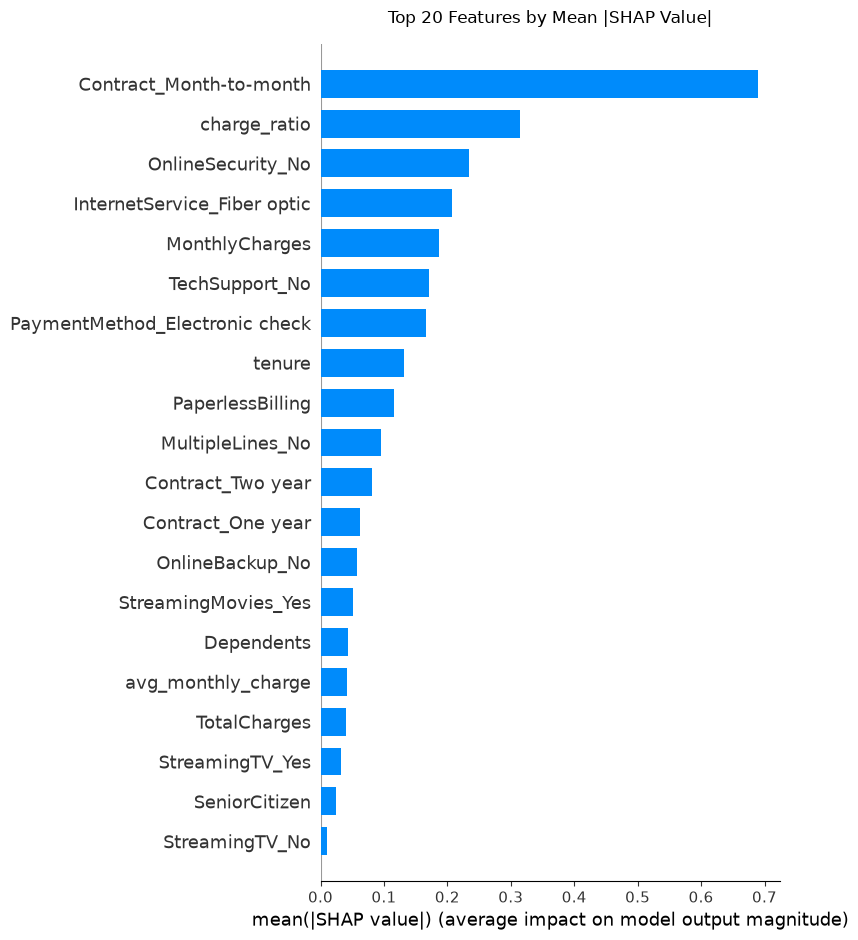

Saved: shap_bar_importance.png


In [4]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_scaled_df,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Top 20 Features by Mean |SHAP Value|", pad=15)
plt.tight_layout()
plt.savefig(ASSET_DIR / "shap_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_importance.png")

SHAP > 0 → feature pushes toward higher predicted churn
SHAP < 0 → feature pushes toward lower predicted churn
SHAP ≈ 0 → little impact on that prediction


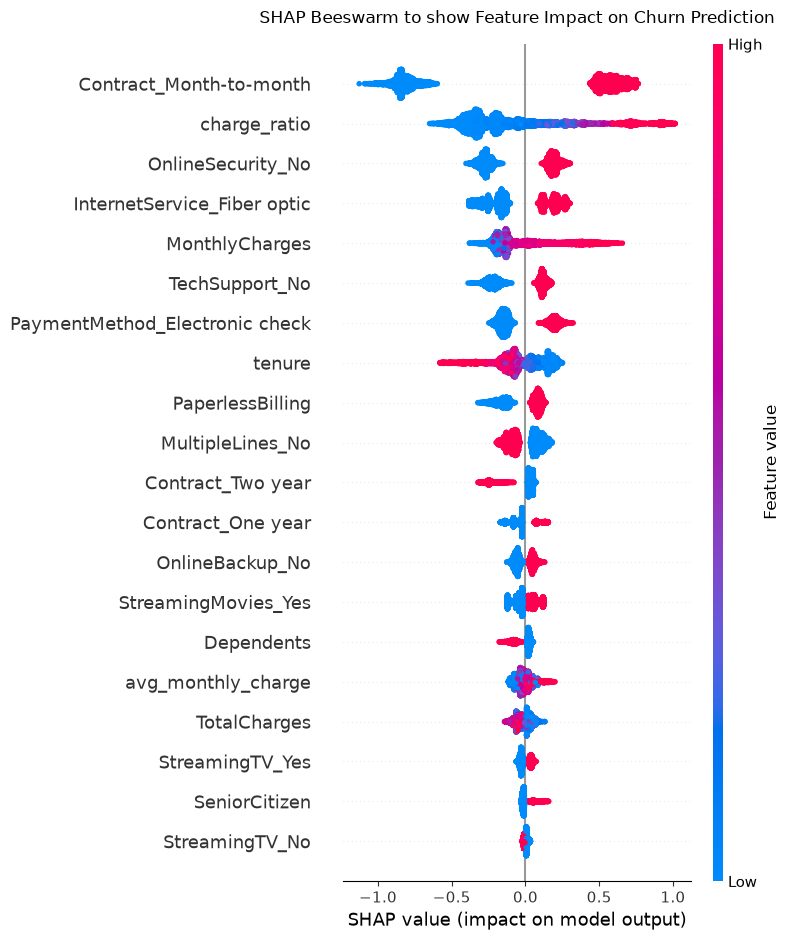

Saved: shap_beeswarm.png


In [5]:


plt.figure()
shap.summary_plot(
    shap_values,
    X_scaled_df,
    max_display=20,
    show=False
)
plt.title("SHAP Beeswarm to show Feature Impact on Churn Prediction", pad=15)
plt.tight_layout()
plt.savefig(ASSET_DIR / "shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")

Using column: Contract_Month-to-month


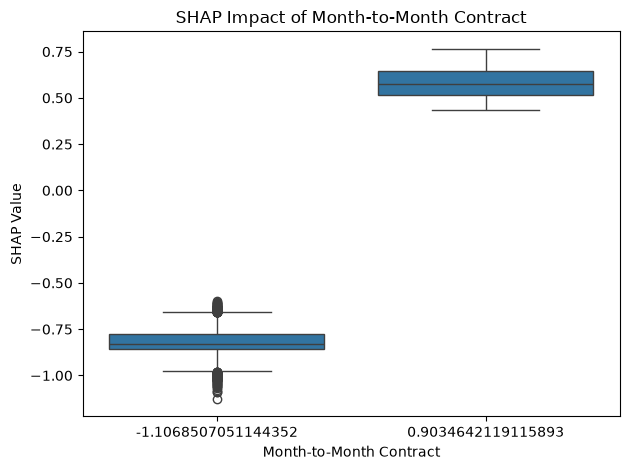

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
contract_col = [c for c in feature_names if 'Contract_Month' in c][0]
print("Using column:", contract_col)

contract_shap = pd.DataFrame({
    'Contract': X_scaled_df[contract_col],
    'SHAP_Value': shap_values[:, X_scaled_df.columns.get_loc(contract_col)]
})

sns.boxplot(
    data=contract_shap,
    x='Contract',
    y='SHAP_Value'
)

plt.title("SHAP Impact of Month-to-Month Contract")
plt.xlabel("Month-to-Month Contract")
plt.ylabel("SHAP Value")
plt.tight_layout()
plt.show()

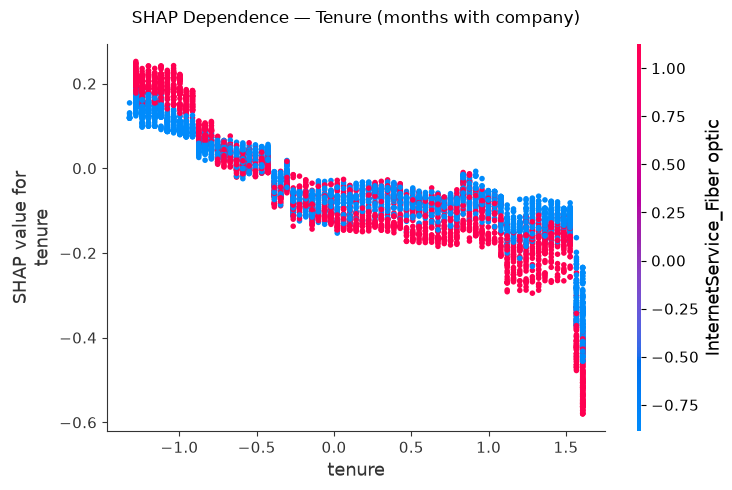

In [7]:
# dependence plot for tenure vs churn 
shap.dependence_plot(
    'tenure',
    shap_values,
    X_scaled_df,
    show=False
)
plt.title("SHAP Dependence — Tenure (months with company)", pad=15)
plt.tight_layout()
plt.show()

Highest churn probability risk customer: index 2208
Predicted churn probability: 0.905
Actual label: Churn


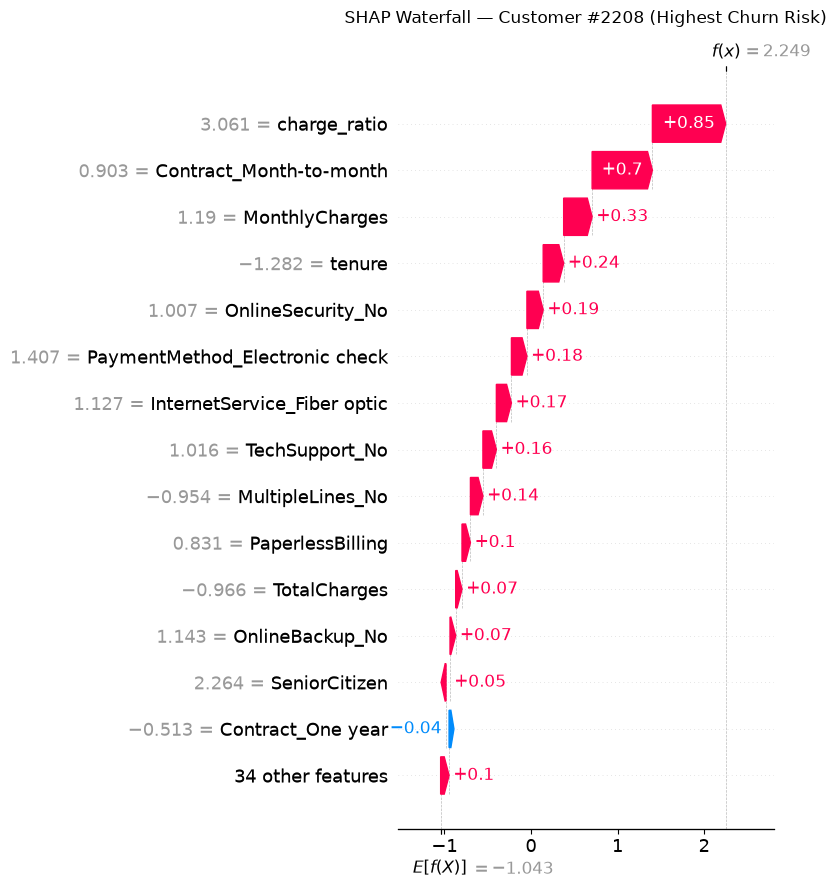

In [8]:
# waterfall plot for a finding customer with high churn risk
churn_probs = best_xgb.predict_proba(X_scaled_df)[:, 1]
highest_risk_idx = churn_probs.argmax()
print(f"Highest churn probability risk customer: index {highest_risk_idx}")
print(f"Predicted churn probability: {churn_probs[highest_risk_idx]:.3f}")
print(f"Actual label: {'Churn' if y.iloc[highest_risk_idx] == 1 else 'No Churn'}")

# Waterfall plot for this customer
shap.plots.waterfall(
    shap.Explanation(
        values      = shap_values[highest_risk_idx],
        base_values = explainer.expected_value,
        data        = X_scaled_df.iloc[highest_risk_idx],
        feature_names = feature_names
    ),
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall — Customer #{highest_risk_idx} (Highest Churn Risk)", pad=15)
plt.tight_layout()
plt.savefig(ASSET_DIR / "shap_waterfall_high_risk.png", dpi=150, bbox_inches='tight')
plt.show()

Lowest churn probability risk customer: index 6374
Predicted churn probability: 0.011
Actual label: No Churn


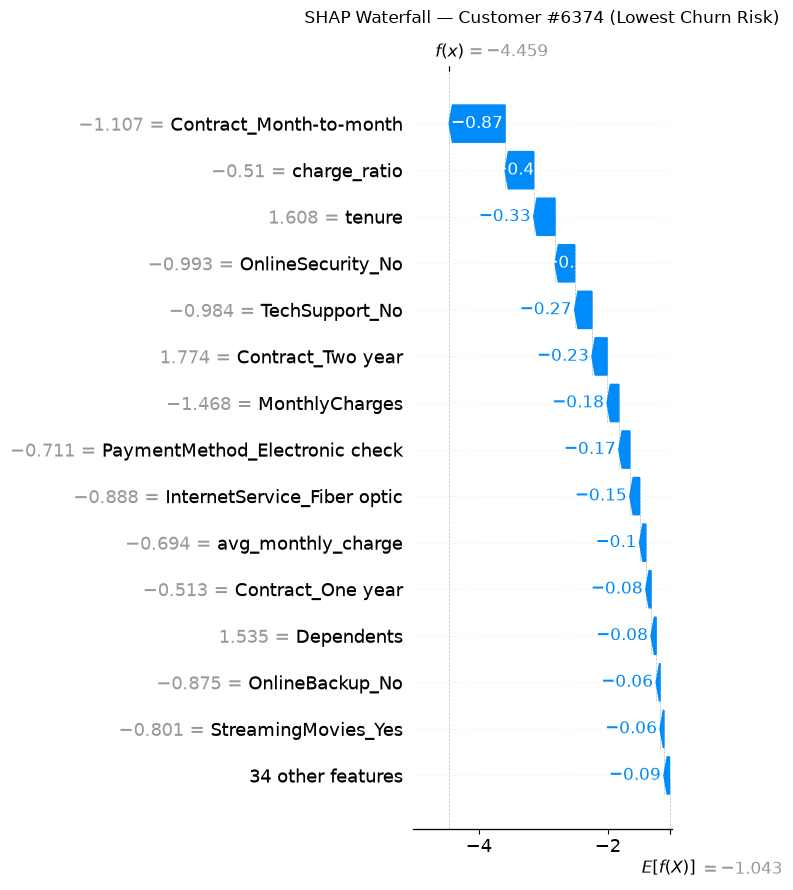

In [9]:
#low risk customer
churn_probs = best_xgb.predict_proba(X_scaled_df)[:, 1]
lowest_risk_idx = churn_probs.argmin()
print(f"Lowest churn probability risk customer: index {lowest_risk_idx}")
print(f"Predicted churn probability: {churn_probs[lowest_risk_idx]:.3f}")
print(f"Actual label: {'Churn' if y.iloc[lowest_risk_idx] == 1 else 'No Churn'}")

# Waterfall plot for this customer
shap.plots.waterfall(
    shap.Explanation(
        values      = shap_values[lowest_risk_idx],
        base_values = explainer.expected_value,
        data        = X_scaled_df.iloc[lowest_risk_idx],
        feature_names = feature_names
    ),
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall — Customer #{lowest_risk_idx} (Lowest Churn Risk)", pad=15)
plt.tight_layout()
plt.savefig(ASSET_DIR / "shap_waterfall_low_risk.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Top 10 features based on mean SHAP values
shap_importance = pd.DataFrame({
    'Feature':    feature_names,
    'Mean_SHAP':  np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

shap_importance.index += 1   # start rank at 1
print("Top 10 Most Important Features (by Mean |SHAP|):\n")
print(shap_importance.head(10).to_string())

shap_importance.to_csv(DATA_DIR / "shap_feature_importance.csv", index=True)


Top 10 Most Important Features (by Mean |SHAP|):

                           Feature  Mean_SHAP
1          Contract_Month-to-month   0.689907
2                     charge_ratio   0.313979
3                OnlineSecurity_No   0.234027
4      InternetService_Fiber optic   0.207785
5                   MonthlyCharges   0.186366
6                   TechSupport_No   0.170456
7   PaymentMethod_Electronic check   0.166519
8                           tenure   0.131697
9                 PaperlessBilling   0.116630
10                MultipleLines_No   0.094587
